# Solving PDE with Tensor Network

## 1. Define a PDE problem 

As an example we will try out the following PDE of 1D (our code up until before DMRG section works will any nD PDE) scalar function $u = u(t, x)$,

$\dfrac{\partial}{\partial t}u = 5xu + \dfrac{\partial}{\partial x}u$

with initial condition $u(0, x) = x$ and boundary condition $u(t, 0) = 0$. Also, consider the simulation in the range $x\in [0, 1]$ and $t\in [0, 1]$. We'll first parse this problem in to a machine readable format. Observe the following code. We will only consider a PDE with linear time derivatives (LT-PDE), i.e., any PDE that can be written with simply $\dfrac{\partial}{\partial t}u$ on the LHS, and the RHS contain no time derivative. Hence, we will only write down the RHS to the `pde_txt` with the following construction rules.
1. Any implicit multiplication must make explicit with `*`.
2. The coordinates in the derivatives $x$, $y$, $z$, ... are represented as `0`, `1`, `2`, ...
3. $\dfrac{\partial}{\partial x}u$ is represented with `D[1, 0]` with the first argument be the differential order and the subsequence arguments specify the axes of differentiations.
4. Any subtraction must be written as addition with $(-1)$ multiply by the subtracting term
5. No division.
6. Any function that is not $u$ or constant would be represented in as list of functions `hs`, e.g., if the PDE is $\dfrac{\partial}{\partial t}u = xu + x^2\dfrac{\partial}{\partial x}u$, then $x$, and $x^2$ will be replaced with `h_0`, and `h_1` both contained in `hs`, i.e., `pde_txt = 'h_1*u+h_2*D[1, 0]'`

In [1]:
pde_txt = '5*h_0*u+D[1, 0]'

Next, we will call our PDE parser class to read, simplify and restructure `pde_txt`.

In [2]:
from utils.pde import PDE

pde = PDE(pde_txt)

Then, we can check out the parsed PDE as followed.

In [3]:
pde.pde

['+', ['*', ['h', 0], 'u', 5.0], ['D', 1.0, 0.0]]

We'll postpone the detail for depicting each `hs`, initial conditions, and boundary conditions after we setting up the finite element (FE) structure.

## 2. Domain triangulation and standard basis

Next, with `Triangulation` class, we can populate the spatial domain with points to partition the domains into smaller elements. The following code will show the code for 2D unit square domain for visualization before going back to our problem 1D unit segment domain. The 2D case use random point sampling while 1D use perturbed uniform grid, both contain extra points to secure the domain corners. As an emperical rule of thumb, the required number of `n_internal_points` grows exponentially with `d`.

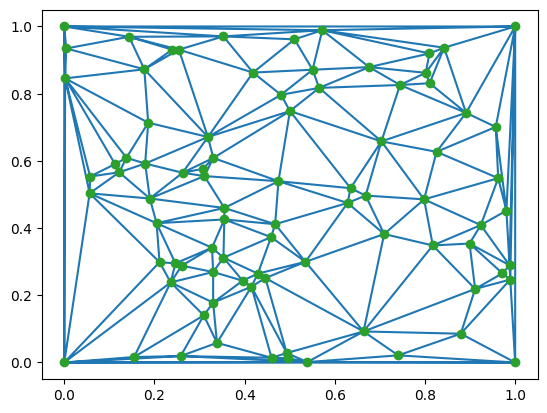

In [4]:
import numpy as np
from utils.triangulation import Triangulation

d_2D = 2
n_internal_points_2D = 81

points_2D = np.concatenate([np.random.random((n_internal_points_2D, d_2D)), 
                         np.array(list(zip(*[coordinate.flatten() for coordinate in np.meshgrid(*([[0, 1]] * d_2D))])))], 
                         axis = 0)

triangulation_2D = Triangulation(points_2D)
triangulation_2D.visualize()

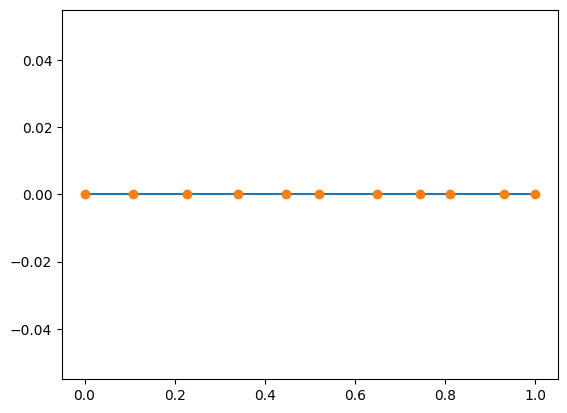

In [5]:
d = 1
n_internal_points = 9

points = np.linspace(0, 1, n_internal_points + 2)
perturbation = 0.05 * np.random.random(n_internal_points + 2)
perturbation[0] = 0
perturbation[-1] = 0
points += perturbation

triangulation = Triangulation(points)
triangulation.visualize()

For 2D case, this is not quite a good set of sampling points. We need more points on the edges to capture the boundary conditions that might come up but user can design and experiment with that.

The next step is to prepare the standard bases of each triangulation unit. Here, we will use simplex triangulation type, e.g., segment for 1D, triangle for 2D, tetrahedral for 3D, etc. The standard means that we will work with simplices with corners at origin and unit Cartesian basis vectors, e.g., $\{(0,), (1,)\}$ for 1D, $\{(0, 0), (1, 0), (0, 1)\}$ for 2D, $\{(0, 0, 0), (1, 0, 0), (0, 1, 0), (1, 0, 0)\}$ for 3D, etc.

For this demo, we will use Lagrange polynomial basis. The following code show how to initialize bases with different polynomial orders (`domain_rank`) in 1D and 2D as well as the visualization of those bases. Note that, the call for 2D case only call the basis function for visualization not create the class object since we don't need to waste time running for basis projection, tensor product reduction, and basis derivative matrices calculations which can take a large over head for high polynomial orders. Also, the 2D visualization use `plt.imshow` which reversed the $y$ axis.

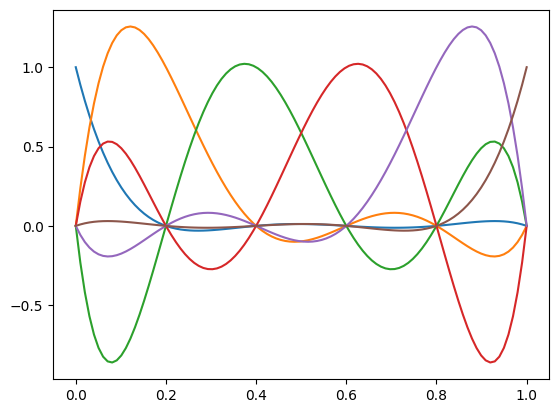

In [6]:
from utils.finite_element import LagrangeBasis

domain_rank = 5
basis = LagrangeBasis(d, domain_rank)
basis.visualize()

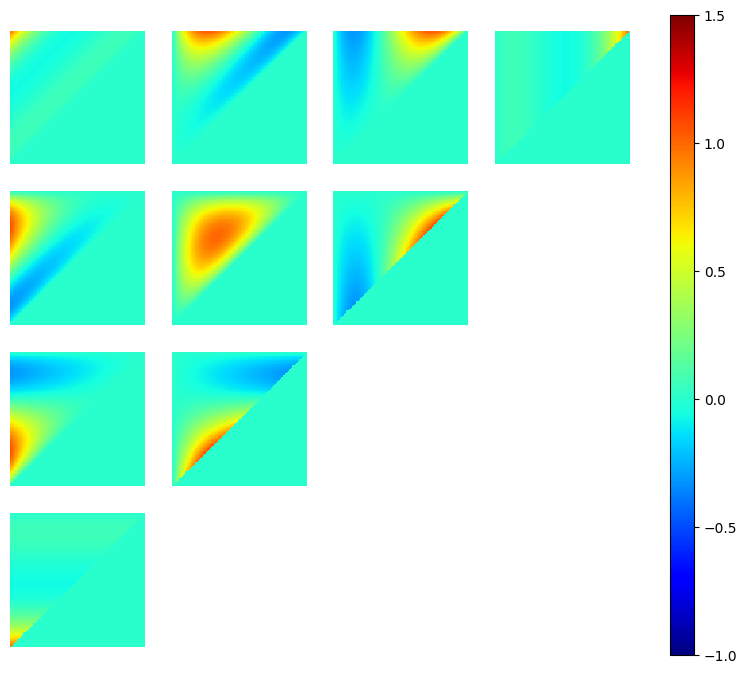

In [7]:
domain_rank_2D = 3
mock_basis_2D = LagrangeBasis(d_2D, domain_rank_2D, mock = True)
mock_basis_2D.visualize()

## 3. FE Structure

The previous part triangulate the problem domain and prepare the standard bases for standard (simplex) domains, but we need the basis that is usable for each element. Since the elements are all simplices. We can apply affine transformation to/from the standard one. One need to be extra careful when do the transformation, e.g., the drivatives transform covariantly while the velocity field transform contravariantly. The `is_contravariant` arguments on some functions is for this purpose, i.e., indicating each tensorial indices whether it is contravariant or not.The `FiniteElement` class handle this management between elements.

In [8]:
from utils.finite_element import FiniteElement

fe = FiniteElement(triangulation, basis)

One might notice, if look through the code, that `FiniteElement` treat each element independently, i.e., any interpolation will most likely discontinuous between adjacent elements for any spatial derivative order, including 0th order. This has influence from discontinuous Galekin method widely use in spectral element method (a sub-category of FEM). Here, instead of using flux correction ponalty, we will allocate the correction to the tensor network optimization as an optimization regularizer.

# 4. Boundary Conditions (BCs)

There are 2 kinds of BCs we are dealing with:
1. Element-Element BCs
2. Element-Environment BCs.

Notice that, with Lagrange polynomial basis, only 2 bases are non-zero at the edge (1D) case. Hence, if element `E_i` is on the left of element `E_j` and the bases are order with the peak positions, the continuity condition is `E_i[-1] - E_j[0] = 0`. Similarly, lets `D_i` and `D_j` represent our derivative projection matrices for `E_i` and `E_j`, respectively, then the smoothness can be enforce with `(D_i @ E_i)[-1] - (D_j @ E_j)[0] = 0`. Also, if `E_i` is on the left edge, and we want the function to be flat at the left edge, then we can use the condition `(D_i @ E_i)[0] = 0`. 

The normal way to deal with this is to write down the conditions into matrix equation, solve for particular and null-space solutions, and work on this basis projection in stead. However, the null-space will most likely not able to be independently factored for each element. Fortunately, this is what the idea of MPS can be very useful because the BCs only directly imposed on adjacent elements. Hence, on top of the main tensor network for solving PDE we will also have a parallel networks that dealt with each BCs, and we will weight sum them as our optimization criteria.

Furthermore, the interpolation of each function in `hs` also need to use this scheme instead of blindly use independent interpolation of `FiniteElement` to ensure their continuity of the interpolation. To be specific, instead of perfectly enforce the BCs exactly with null-space calculation, we will co-optimize the main objective together with the BCs, e.g., with `E_i[-1] - E_j[0] = 0` condition, we will try to minimize `(E_i[-1] - E_j[0])^2` this can be written as a variational problem of 2-node tensor network operator. For the Element-Environment BCs, we can do with 1-node tensor network operator. Furthermore, with sequencial optimization scheme like in DMRG, only a few of these BCs matter in each optimization step. One can also easily apply this idea to the higher dimension case since all BCs are between a pair of adjacent elements or an element to the envirenment. 

We wrap this function for Element-Element BCs with the highest `continuity_order`, i.e., enforce continuity upto that spatial derivatives. Note that, for higher dimensions, there are more than a pair of bases that need to be matched per BC. Hence, we need to choose a proper `domain_rank` so that the degree of freedom of the element won't completely run out. For coding purpose, the BC tensor network operator will be slightly different for the same BC but when optimizing each of the element. This is for the higher dimension case when there is multiple neighbors. The following code construct tensor network operator for the continuity up to the first differentiation. The shape of the operator should be `(n, d + 1, r + 1, r + 1, r + 1, r + 1)` where `n` is number of elements, `d + 1` is number of sides of each simplex, and `r` is basis rank. The `+ 1` to `r` comes from the tensor product trick that make it possible to subtract the representations from different elements.

In [9]:
con_order = 2

In [10]:
fe.set_con_bc_operators(con_order)
fe.con_bc_operators.shape

(10, 2, 7, 7, 7, 7)

Since the continuity condition can be applied to any axes of the function, we can generalize the `fe.con_bc_operators` by broadcasting to those indices. For example, if `u` is a rank 2 3D tensor:

In [11]:
fe.set_u_shape((3, 3))
fe.con_bc_operators.shape

(10, 2, 55, 55, 55, 55)

However, for this demo, `u` is a scalar function.

In [12]:
fe.set_u_shape(tuple())
fe.con_bc_operators.shape

(10, 2, 7, 7, 7, 7)

The Element-Environment BCs require a deeper preparation. The current code cannot automatically search the elements that intersect the boundaries. User need to manually provide this part. `env_bcs` is a linked dictionary with the outer layer indicate the element, and the inner indicate the side of which the element faces environment instead of other element. The BCs that govern this side (we'll assume that we place our elements such that the boundaries coincide with some elements' boundaries) can be described as `m` equations each of which is a linear combination of some derivarives of `u` that equate to some constant. In particular, each BC is a tuple of two entries. The first is a list of factors for each derivative orders from zeroth, first, second, etc. Note that for `d` dimensional problem, the `n` order derivatives has `d ** n` components. Hence, each term is an `(m, d, ..., d, r)` array where there are `n+p` number of `d`'s where the first `n` is from derivatives and the last `p` is from the shape of tensor `u` and `r` is the number of rank of the elements that expose to that side. The second is an array that is the result of those linear combination. Hence, it is an array of size `(m, d, ..., d, 1)` where there are `p` number of `d`'s. 

For our demo, the only Element-Environment BC is $u(t, 0) = 0$ which only involve the element 0 on neigher 1 side (left). The condition only has 1 equation on one rank and only has the zeroth derivative term which equate its scalar value to 0.

In [13]:
env_bcs = {0: {1: ([np.array([[1]])], np.array([[0]]))}}

After the preparation of the Element-Environment BCs information. We can construct the operator for them with the following code. The shape of the operator should be `(r + 1, r + 1)` where `r` is basis rank.

In [14]:
fe.set_env_bc_operators(env_bcs)
fe.env_bc_operators[0][1].shape

(7, 7)

# 5. Tensor Network

Now we are ready to perform the magic. There are 3 type of tensor network we need to construct:
1. BC networks
2. interpolation networks
3. main PDE network

Each of these can be handle with our `TensorNetwork` class. Note that, the main PDE network relies on the results of interpolation. Hence, we cannot construct the PDE network yet.

In [15]:
from utils.tensor_network import TensorNetwork

tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)

# 6. Interpolation Subroutine

This section will show how to construct interpolation network with constraints given by BC network that will be used by the main PDE network. Looking back at the PDE 

$\dfrac{\partial}{\partial t}u = 5xu + \dfrac{\partial}{\partial x}u$,

we can see that the only interpolation task are for $x$ into our basis as well as the initial condition (which is the same function, $x$, for this example). The remaining parts are the target function, derivative of target function and the target function of the previous round, all of which are already in our basis representations. 

The main idea for the interpolation is that we write down a naive independent projection by `fe` as our network operator, and then we balance the square loss between our state to the projection with the loss due to the continuity conditions.

Before that, let's check the credibility of the basis used for interpolation with test function $e^{-x^2}$ on the range $[0, 1]$. We define the function, pass it to representation projection, then reconstruct the function back.

In [16]:
fun_gauss = lambda x: np.exp(-np.array(x)**2)
rep_gauss = basis.element_fun2rep(fun_gauss)
rec_gauss = basis.element_rep2fun(rep_gauss)

We can plot out the reconstruction as follow.

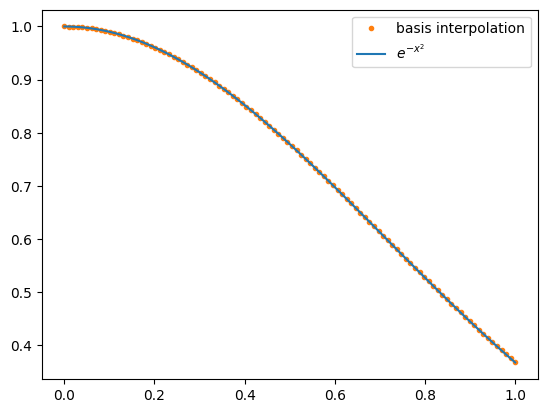

In [17]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 100)

plt.figure()
plt.plot(x, rec_gauss(x), '.C1', label = 'basis interpolation')
plt.plot(x, fun_gauss(x), 'C0', label = r'$e^{-x^2}$')
plt.legend()
plt.show()

Not, bad. Then, we can check the derivative feature of the basis by applying derivative tensor directly to the representation of the function and reconstruct the function. We can compare directly from analytic differentiation, $-2xe^{-x^2}$

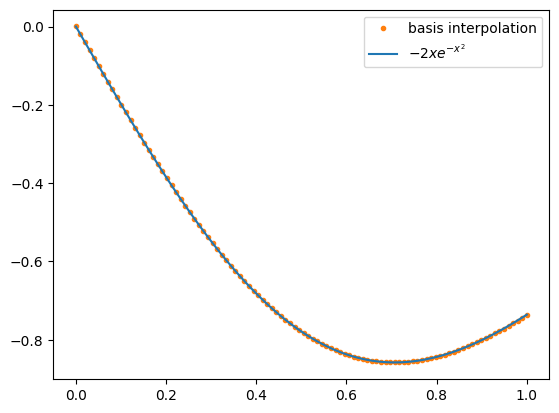

In [18]:
fun_prime_gauss = lambda x: -2 * np.array(x) * np.exp(-np.array(x)**2)
rep_prime_gauss = basis.diff(rep_gauss, dim = 0)
rec_prime_gauss = basis.element_rep2fun(rep_prime_gauss)

x = np.linspace(0, 1, 100)

plt.figure()
plt.plot(x, rec_prime_gauss(x), '.C1', label = 'basis interpolation')
plt.plot(x, fun_prime_gauss(x), 'C0', label = r'$-2xe^{-x^2}$')
plt.legend()
plt.show()

We can also check the representation tensor product reduction feature of $e^{-x^2}$ with other function $x^2$ in our representation.

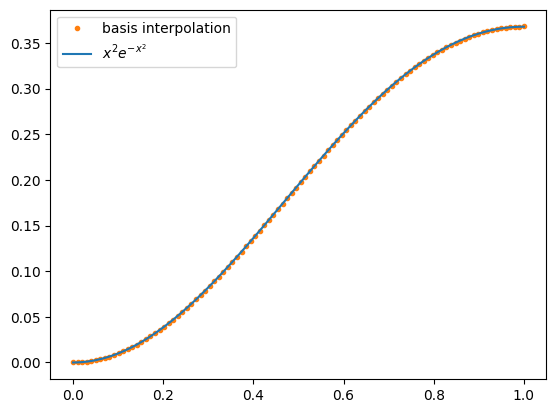

In [19]:
fun_square = lambda x: np.array(x)**2
rep_square = basis.element_fun2rep(fun_square)

fun_square_gauss = lambda x: np.array(x)**2 * np.exp(-np.array(x)**2)
rep_square_gauss = basis.tp(rep_gauss, rep_square)
rec_square_gauss = basis.element_rep2fun(rep_square_gauss)

x = np.linspace(0, 1, 100)

plt.figure()
plt.plot(x, rec_square_gauss(x), '.C1', label = 'basis interpolation')
plt.plot(x, fun_square_gauss(x), 'C0', label = r'$x^2e^{-x^2}$')
plt.legend()
plt.show()

After seeing the credibility of the basis, we will perform the naive interpolation with the finite elements, and reconstruct the function $x$ from this representation, i.e., independently interpolate each element to the section of the function responsible by the elemental domain.

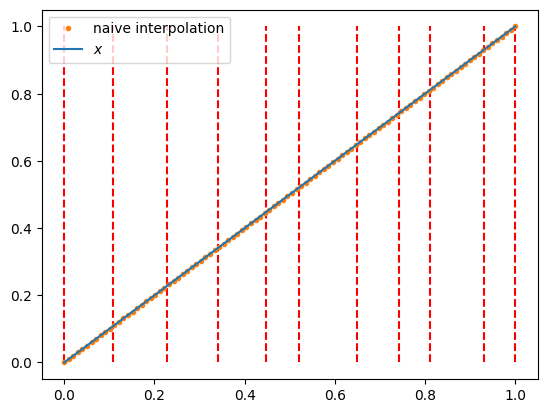

In [20]:
fun = lambda x: x
rep_naive = fe.fun2rep(fun)
rec_naive = fe.rep2fun(rep_naive)

x = np.linspace(0, 1, 100)

plt.figure()
plt.vlines(triangulation.points, ymin = 0, ymax = 1, colors = 'r', linestyles = '--')
plt.plot(x, rec_naive(x), '.C1', label = 'naive interpolation')
plt.plot(x, fun(x), 'C0', label = r'$x$')
plt.legend()
plt.show()

This show a very good interpolation which raise the question about whether the continuity is necessary. To demonstrate the need, let's consider a more challenging function $\sin(100x)$.

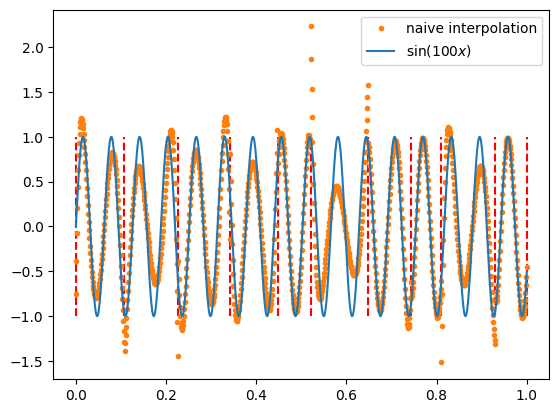

In [21]:
fun_sin100 = lambda x: np.sin(100*x)
rep_sin100_naive = fe.fun2rep(fun_sin100)
rec_sin100_naive = fe.rep2fun(rep_sin100_naive)

x = np.linspace(0, 1, 1000)

plt.figure()
plt.vlines(triangulation.points, ymin = -1, ymax = 1, colors = 'r', linestyles = '--')
plt.plot(x, rec_sin100_naive(x), '.C1', label = 'naive interpolation')
plt.plot(x, fun_sin100(x), 'C0', label = r'$\sin(100x)$')
plt.legend()
plt.show()

Obviously, the result will highly depend on the triangulation. The larger element will struggle to fit in many loop of sinusoidal function. However, this is not the main problem. The main idea behind FEM is to make the triangulation finer around the area we expected to have more abrupt change. Hence, the fact that the basis rank is not enough to represent the function is the issue of not having enough element or basis rank for those regions. The issue is more about the fact that we are trying to solve first order differential equation which most likely require the first derivative of the representation to be continuous which we can directly observe below.

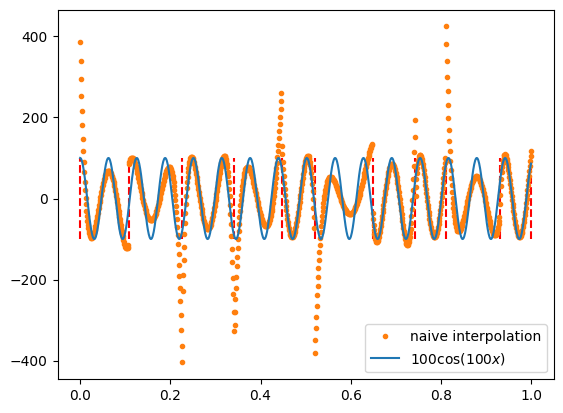

In [22]:
fun_prime_sin100 = lambda x: 100*np.cos(100*x)
rep_prime_sin100_naive = fe.all_diff(rep_sin100_naive, dim = 0)
rec_prime_sin100_naive = fe.rep2fun(rep_prime_sin100_naive)

x = np.linspace(0, 1, 1000)

plt.figure()
plt.vlines(triangulation.points, ymin = -100, ymax = 100, colors = 'r', linestyles = '--')
plt.plot(x, rec_prime_sin100_naive(x), '.C1', label = 'naive interpolation')
plt.plot(x, fun_prime_sin100(x), 'C0', label = r'$100\cos(100x)$')
plt.legend()
plt.show()

Of course, this can be mitigate with fine enough triangulation as well, but we would like the continuity of the interpolation to be more integrated, i.e., directly restrict the basis functions to obey this restriction as much as possible for any triangulation choices. 

Note that, in FEM, it is a standard practice to reduce the differential order with integration by part when using the weak formalism. The idea can be apply with our method as well. However, that's not the main thing we want to present. We will assume that our current PDE is the result of exhausting every trick in the book to reduce the differential order.

To solve the continuity issue, we will construct interpolation network and optimize together with the BC networks. First, we need the operator for interpolation.

In [23]:
domain_basis_fun_overlap = fe.get_domain_basis_fun_overlap(fun_sin100)
interpolation_operators = tn.get_operators_from_basis_interpolation(basis.basis_overlap, domain_basis_fun_overlap)
tn.set_operators(interpolation_operators)

Then, add ansatz initialization along with the boundary conditions operators. One can either use random initialization or use the result from naive interpolation as the initial guess for the ansatz. We'll use naive interpolation as our starting point. Since the naive interpolation would already give a decent interpolation. Because we expected the actual solution of this kind of task to give non-entangled answer, we can safely assume the `bond_order` of the ansatz to be 1. However, if the operator is expected to give entangled result, our ansatz should be of larger bond order as well.

In [24]:
bond_order = 1

states = np.ones((triangulation.n, domain_basis_fun_overlap.shape[1] + 1, bond_order, bond_order))
states[:, :-1, :, :] = rep_sin100_naive[..., None, None]
states[:, -1] = 1

tn.set_states(states.copy(), bond_order)
tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators)

We are now ready to use DMRG to solve for the optimum state that both interpolate and some what continuous to the first derivative. Note that we don't want to use the Element-Environment BCs of the main PDE networks if there is no special requirement. Otherwise, we need to specify another boundary condition operators for the functions that would be interpolated. In this case, we will not.

In [25]:
from utils.solver import DMRG

tn.set_solver(DMRG())
opt_states = tn.solve(rounds = 20, alpha = 1E-8, env = False)

(7, 1, 1)
(7, 1, 1) 9 0 (1, 1)
(7, 1, 1) 8 0 (1, 1)
(7, 1, 1) 7 0 (1, 1)
(7, 1, 1) 6 0 (1, 1)
(7, 1, 1) 5 0 (1, 1)
(7, 1, 1) 4 0 (1, 1)
(7, 1, 1) 3 0 (1, 1)
(7, 1, 1) 2 0 (1, 1)
(7, 1, 1) 0 1 (1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1) 9 0 (1, 1)
(7, 1, 1) 8 0 (1, 1)
(7, 1, 1) 7 0 (1, 1)
(7, 1, 1) 6 0 (1, 1)
(7, 1, 1) 5 0 (1, 1)
(7, 1, 1) 4 0 (1, 1)
(7, 1, 1) 3 0 (1, 1)
(7, 1, 1) 2 0 (1, 1)
(7, 1, 1) 0 1 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7, 1, 1)
(7, 1, 1) 1 0 (1, 1)
(7

We can, then, extract the resulting representation and compare it to the naive interpolation one as shown below. We cannot expected the interpolation to be that much better than the naive version since the continuity would reduce the degree of freedom of our ansatz. However, we can clearly see that the result from optimizing tensor network give a much smoother answer at the element boundaries.

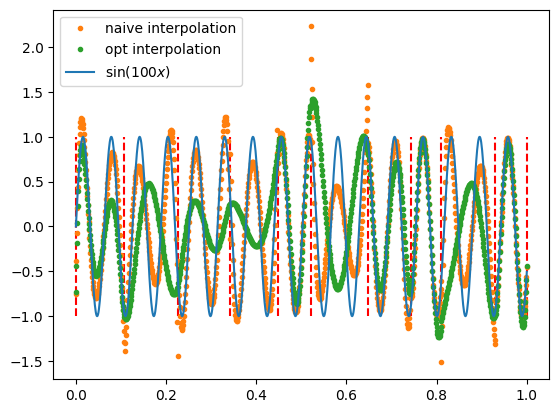

In [26]:
rep_sin100_opt = opt_states.tensor[..., :-1, 0, 0]
rec_sin100_opt = fe.rep2fun(rep_sin100_opt)

x = np.linspace(0, 1, 1000)

plt.figure()
plt.vlines(triangulation.points, ymin = -1, ymax = 1, colors = 'r', linestyles = '--')
plt.plot(x, rec_sin100_naive(x), '.C1', label = 'naive interpolation')
plt.plot(x, rec_sin100_opt(x), '.C2', label = 'opt interpolation')
plt.plot(x, fun_sin100(x), 'C0', label = r'$\sin(100x)$')
plt.legend()
plt.show()

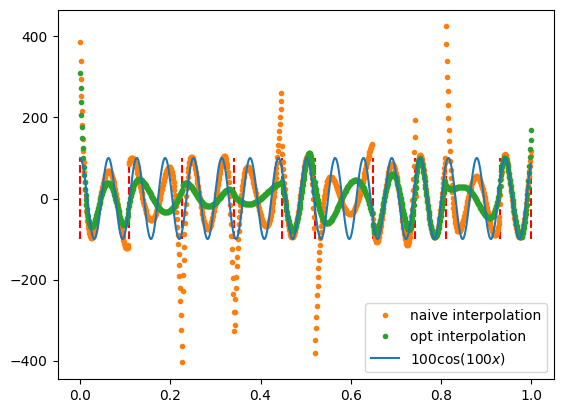

In [27]:
rep_prime_sin100_opt = fe.all_diff(rep_sin100_opt, dim = 0)
rec_prime_sin100_opt = fe.rep2fun(rep_prime_sin100_opt)

x = np.linspace(0, 1, 1000)

plt.figure()
plt.vlines(triangulation.points, ymin = -100, ymax = 100, colors = 'r', linestyles = '--')
plt.plot(x, rec_prime_sin100_naive(x), '.C1', label = 'naive interpolation')
plt.plot(x, rec_prime_sin100_opt(x), '.C2', label = 'opt interpolation')
plt.plot(x, fun_prime_sin100(x), 'C0', label = r'$100\cos(100x)$')
plt.legend()
plt.show()

# 7. Solving PDE

The fact that we limited the problem into LT-PDE make it possible to isolate the time derivatives parts as the iterative application of tensor network optimization subroutine for the spatial derivatives. We will use the simplest form of implicit Euler method for this demo. (one can use any of the higher degree finite difference methods)

The process will be as followed:
1. Construct the main PDE, and BC networks.
2. Construct and interpolate all functions in `h_s` with interpolation and BC networks co-optimization. (might need to be done at every time step if the function is time dependent)
3. Construct and interpolate initial condition function.
4. Solve the main PDE for the next time step.
5. Redo step 2 if needed. (no need for this demo's PDE)
6. Redo step 4 with the solution from step 4 (of the previous round) as the new initial condition. (no need to reinterpolate since it already in the MPS format)

## 7.1 PDE Network

Recall the PDE that we parsed in the first section. We'll feed the parsed PDE to the `tn` to construct the PDE network. First, we need to let the network know the shape of the PDE solution, i.e., is it a scalar, vector, tensor, etc. In our case, it is a scalar.

In [28]:
tn.set_u_shape(tuple())

It also require the basis representation of the `h_0` which is the function $x$ which we have seen that the naive interpolation already did a good job capturing the function smoothly.

In [29]:
from utils.tensor_network import TensorUnit

blank_states = np.ones((triangulation.n, domain_basis_fun_overlap.shape[1] + 1, bond_order, bond_order))

h_0_state = blank_states.copy()
h_0_state[:, :-1] = rep_naive[..., None, None]
h_tensor_units = [TensorUnit(h_0_state, 1, [1, 1], 0)]
tn.set_h_tensor_units(h_tensor_units)

Then, we can construct the operator for PDE network. Remember that one need the time step size $\Delta$ and the states at the previous time step to predict the next time step states. For the first time step, the previous time step state is the state interpolated from the initial condition $u(0, x) = x$.

In [30]:
delta = 0.01
states = TensorUnit(h_0_state.copy(), 1, [1, 1], 0)
pde_operators =  tn.get_operators_from_pde(pde.pde, delta, states)

One thing we need to be careful is that the PDE can involve any number of non-linear tensor product of `u`. The last dimension of the operator might not be quite fit with the states as shown below.

In [31]:
states.shape, pde_operators.shape

((10, 7, 1, 1), (10, 8, 16, 16, 8))

Normally, when performing tensor network, we would expected the second rank of the `states` (7) to match the last rank of the `operators` (8). Here, first rank is reserved for element indicator indices. There reason behind this is that the PDE contains a term that doesn't involve `u`, i.e., the `u` at the previous time step. In fact, if the PDE contains something like $u\dfrac{\partial}{\partial x}u$ then there would be a term that in volve the ternsor product of `u` with itself. Hence, we can expected the `operators` to have the last rank of the form $\sum_i (r+1)^p_i$ where $p_i$ is the tensor product power of `u` of the $i$ th term. Because of this, the command for solving the PDE network will be slightly different from the interpolation network due to the extra step that require stacking of different tensor product power of `u`. The process can be generalized together.

### todo: generalize interpolation and PDE network together

As before, we will load the operators and initial guess of the states to `tn` and solve it, but, this time, with Element-Environment BCs turned on.

In [33]:
tn.solver.states.shape

(10, 7, 1, 1)

In [32]:
tn.set_operators(pde_operators)

states = h_0_state.copy()
tn.set_states(states.copy(), bond_order)

opt_states = tn.solve(rounds = 20, alpha = 1E-8, env = True, pde = (True, [0, 1]))

(8, 1, 1)
(7, 1, 1) 9 0 (1, 16, 1)


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (8,16,16,8)->(8,newaxis,16,newaxis,16,8) (7,1,16,1)->(1,newaxis,1,16,7) 